# estimatebg


In [1]:
source /export/ciao/bin/ciao.bash -o
PFILES="./param;$ASCDS_INSTALL/param:$ASCDS_INSTALL/contrib/param"
mkdir -p ./param
ASCDS_WORK_PATH=./

CIAO configuration is complete... 
CIAO 4.9 Friday, December  2, 2016
  bindir      : /export/ciao-4.9/bin
  CALDB       : 4.7.3


In [2]:
/bin/rm -rf 578 
download_chandra_obsid 578


  Type     Format      Size  0........H.........1  Download Time Average Rate
  ---------------------------------------------------------------------------
  readme   ascii      10 Kb  ####################          < 1 s  64.9 kb/s
  oif      fits       25 Kb  ####################          < 1 s  220.0 kb/s
  vv       pdf        46 Kb  ####################          < 1 s  1303.5 kb/s
  cntr_img fits      129 Kb  ####################          < 1 s  1808.6 kb/s
  cntr_img jpg       575 Kb  ####################          < 1 s  4828.5 kb/s
  evt2     fits       10 Mb  ####################          < 1 s  20510.3 kb/s
  full_img fits       76 Kb  ####################          < 1 s  1489.2 kb/s
  full_img jpg        69 Kb  ####################          < 1 s  1761.0 kb/s
  src2     fits       13 Kb  ####################          < 1 s  1977.9 kb/s
  src_img  jpg        71 Kb  ####################          < 1 s  2484.4 kb/s
  bpix     fits       19 Kb  ####################          < 1 s 

In [3]:
chandra_repro 578 out=`pwd` clobber=yes


Processing input directory '/data/sdsreg/thread_output/CIAO4.9/estimatebg/578'

Resetting afterglow status bits in evt1.fits file...

Running the destreak tool on the evt1.fits file...

Running acis_build_badpix and acis_find_afterglow to create a new bad pixel file...

Running acis_process_events to reprocess the evt1.fits file...
Output from acis_process_events:
# acis_process_events (CIAO 4.9): WARNING: problem reading tgainfile, tgain adjustment will not be applied. Changing apply_tgain=yes to apply_tgain=no.
# acis_process_events (CIAO 4.9): WARNING: problem reading ctifile, cti adjustment will not be applied. Changing apply_cti=yes to apply_cti=no.
Filtering the evt1.fits file by grade and status and time...
Applying the good time intervals from the flt1.fits file...
The new evt2.fits file is: /data/sdsreg/thread_output/CIAO4.9/estimatebg/acisf00578_repro_evt2.fits

Updating the event file header with chandra_repro HISTORY record
Creating FOV file...
Setting observation-specific

## Create Image

In [4]:
fluximage acisf00578_repro_evt2.fits"[ccd_id=7]" 3C295 bin=2 band=broad clob+

Running fluximage
Version: 12 September 2016

Using CSC ACIS broad science energy band.
Aspect solution pcadf052378346N003_asol1.fits found.
Bad-pixel file acisf00578_repro_bpix1.fits found.
Mask file acisf00578_000N003_msk1.fits found.

The output images will have 695 by 695 pixels, pixel size of 0.984 arcsec,
    and cover x=3506.5:4896.5:2,y=3676.5:5066.5:2.

Running tasks in parallel with 4 processors.
Creating aspect histogram for obsid 578
Creating instrument map for obsid 578
Creating exposure map for obsid 578
Thresholding data for obsid 578
Exposure-correcting image for obsid 578

The following files were created:

 The clipped counts image is:
     3C295_broad_thresh.img

 The clipped exposure map is:
     3C295_broad_thresh.expmap

 The exposure-corrected image is:
     3C295_broad_flux.img



## Add field of view info into file so down stream tools know where the chip edges are

In [5]:
dmcopy "3C295_broad_thresh.img[sky=region(acisf00578_repro_fov1.fits[ccd_id=7])][opt full]" \
  3C295_broad_dss.img cl+

In [6]:
dmlist 3C295_broad_dss.img subspace 

 
--------------------------------------------------------------------------------
Data subspace for block EVENTS_IMAGE: Components: 1 Descriptors: 17 
--------------------------------------------------------------------------------
 
 --- Component 1 --- 
   1 sky                  Real8               Polygon(3920.05,5065.26,3507.36,4132.99,3507.36,4132.91,3507.35,4089.62,4439.65,3676.88,4482.9,3676.93,4482.96,3676.98,4895.6,4609.28,4895.6,4652.57,4895.52,4652.67,3963.25,5065.26,3920.18,5065.28,3920.05,5065.26)
   1 sky                  Real8               Field area = 1.9321e+06 Region area = 1.15789e+06

   1 sky                  [ 1] x                   3507.350:     4895.60 
   1 sky                  [ 2] y                   3676.880:     5065.280 
   2 expno                Int4                3:5876 
   3 ccd_id               Int2                7:7 
   4 node_id              Int2                0:3 
   5 chipx                Int2                1:1024 
   6 chipy                I

## Get max pixel value

also see number of null pixels is > 0

In [7]:
dmstat 3C295_broad_dss.img cen-

EVENTS_IMAGE
    min:	0 	      @:	( 4439.5 3677.5 )
    max:	314 	      @:	( 4035.5 4279.5 )
   mean:	0.11769399768 
  sigma:	0.80619974062 
    sum:	34071 
   good:	289488 
   null:	193537 


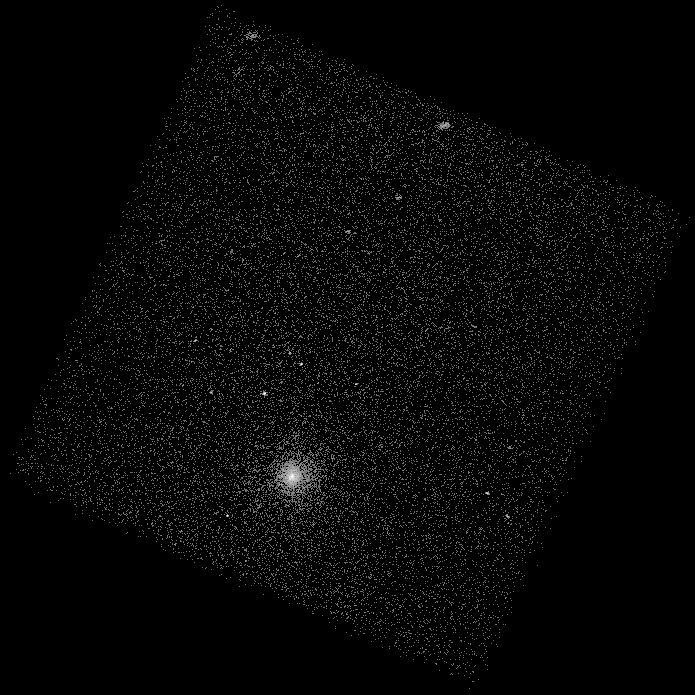

In [8]:
dmimg2jpg infile=3C295_broad_dss.img outfile=3C295_broad_dss.jpg\
  scalefun=log clob+ minred=0 maxred=50 mode=h

display < 3C295_broad_dss.jpg

## Smooth Image

In [9]:
pset aconvolve infile=3C295_broad_dss.img
pset aconvolve outfile=3C295_broad_dss_sm.img
pset aconvolve kernelspec="lib:gaus(2,5,1,3,3)"
pset aconvolve meth=fft
aconvolve mode=h clob+

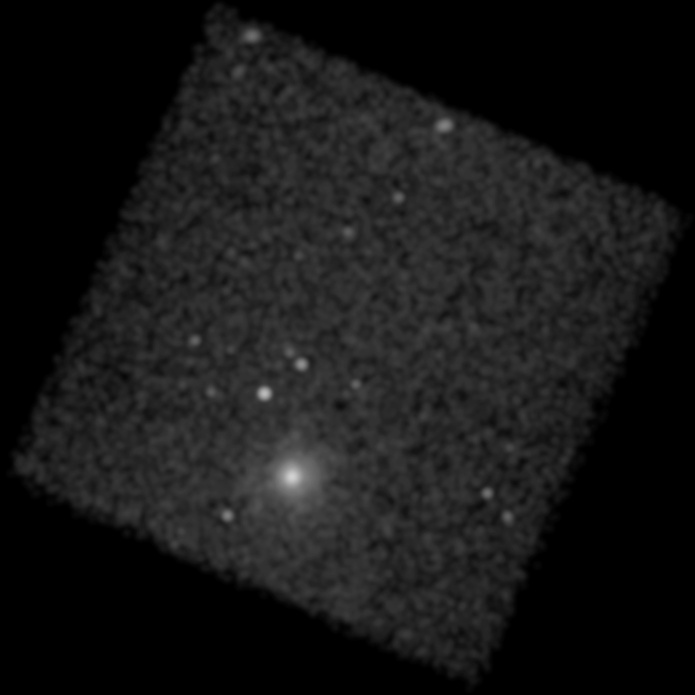

In [10]:
dmimg2jpg infile=3C295_broad_dss_sm.img outfile=3C295_broad_dss_sm.jpg\
  scalefun=log clob+ minred=0 maxred=50 mode=h

display < 3C295_broad_dss_sm.jpg

## Median Ring

In [11]:
pset dmimgfilt infile=3C295_broad_dss_sm.img
pset dmimgfilt outfile=3C295_broad_dss.bg
pset dmimgfilt function=median
pset dmimgfilt mask="annulus(0,0,20,22)"
dmimgfilt mode=h clob+

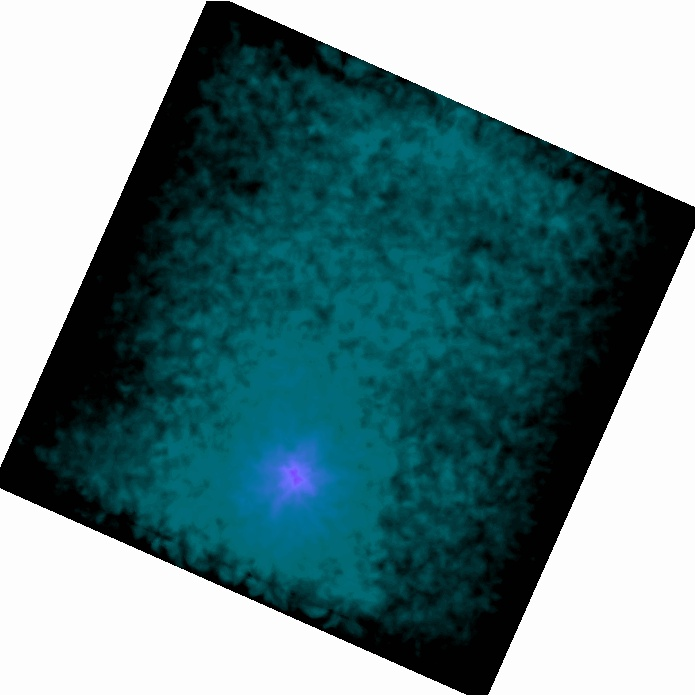

In [12]:
dmimg2jpg infile=3C295_broad_dss.bg outfile=3C295_broad_dss.bg.jpg\
  scalefun=log clob+ minred=0 maxred=50 mode=h lut=")imagej_lut.cequal"

display < 3C295_broad_dss.bg.jpg

## Using with Wavdetect

In [13]:
# Skip reproject_image, already same size/scale/tan

### Same as before, add FOV info to expmap file subspace

In [14]:
dmcopy "3C295_broad_thresh.expmap[sky=region(acisf00578_repro_fov1.fits[ccd_id=7])][opt full]" \
  3C295_broad_dss.expmap cl+

### Smooth expmap on same scale as counts

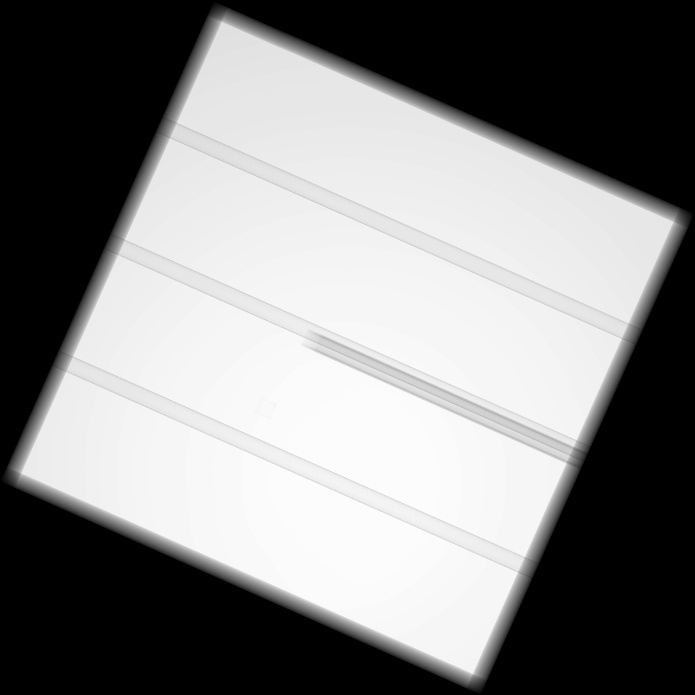

In [15]:
dmimg2jpg infile=3C295_broad_dss.expmap outfile=3C295_broad_dss.expmap.jpg\
  scalefun=linear clob+ minred=0 mode=h

display < 3C295_broad_dss.expmap.jpg

### Smooth exposure map.  We want to use `mean` here instead of median.

In [16]:
dmimgfilt 3C295_broad_dss.expmap 3C295_broad_dss_sm.expmap \
  mean "annulus(0,0,20,22)" cl+

### Get max pixel value, need for normalization

In [17]:
dmstat 3C295_broad_dss_sm.expmap cen-

3C295_broad_dss_sm.expmap
    min:	1712700.125 	      @:	( 3919.5 5063.5 )
    max:	7232186 	      @:	( 4287.5 4121.5 )
   mean:	6310085.5422 
  sigma:	1086469.6164 
    sum:	1.8266940435e+12 
   good:	289488 
   null:	193537 


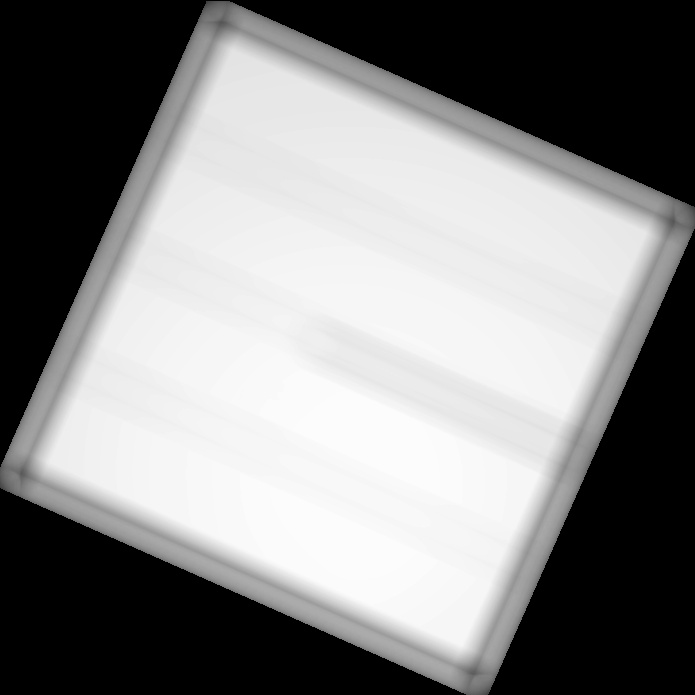

In [18]:
dmimg2jpg infile=3C295_broad_dss_sm.expmap outfile=3C295_broad_dss_sm.expmap.jpg\
  scalefun=linear clob+ minred=0 mode=h maxred=7232186

display < 3C295_broad_dss_sm.expmap.jpg

### Scale background, `img1`, by the exposure map, `img2`, normlizaed by the max exposure value.

In [19]:
dmimgcalc 3C295_broad_dss.bg,3C295_broad_dss_sm.expmap none \
  3C295_broad_dss.nbkg op="imgout=(img1/(img2/7232186))" cl+

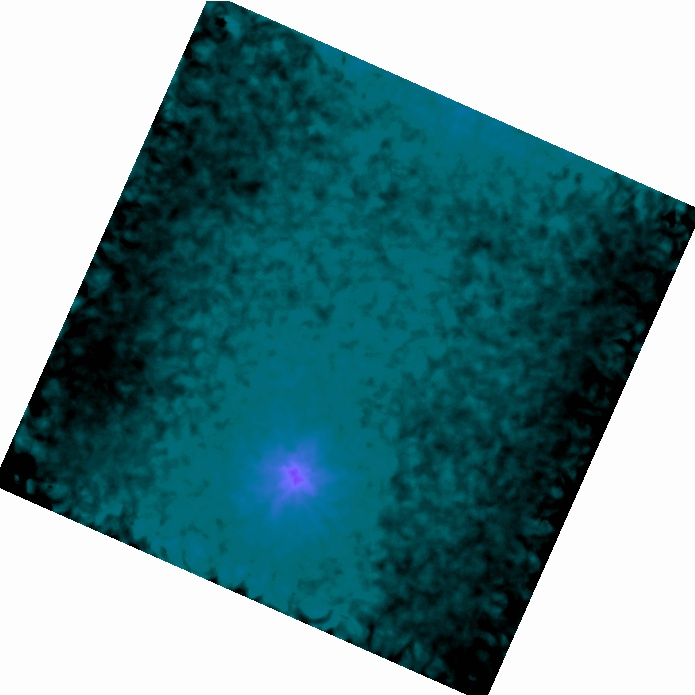

In [20]:
dmimg2jpg infile=3C295_broad_dss.nbkg outfile=3C295_broad_dss.nbkg.jpg\
  scalefun=log clob+ minred=0 mode=h maxred=50 lut=")imagej_lut.cequal"

display < 3C295_broad_dss.nbkg.jpg

In [21]:
# pset wavdetect bkginput=3C295_broad_dss.nbkg 

# Cleanup


In [ ]:
/bin/rm -rf 578
/bin/rm -rf acisf*fits pcadf*.fits acisf*.lis 
